In [4]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, Callback

In [3]:
path = r'C:\Users\aayis\OneDrive\Desktop\UWL\PROJECT\DNS_Covert_Channel_Detection\dns_project'
csv_files = [f for f in os.listdir(path) if f.lower().endswith('.csv')]
all_data = []

print(f"🔄 Starting merge for {len(csv_files)} files...")

for f in csv_files:
    file_path = os.path.join(path, f)
    try:
        df_temp = pd.read_csv(file_path, nrows=50000)
        df_temp['label'] = 0 if 'benign' in f.lower() else 1
        all_data.append(df_temp)
        print(f"✅ Merged {f}")
    except Exception as e:
        print(f"❌ Failed to read {f}: {e}")

if all_data:
    df = pd.concat(all_data, ignore_index=True)
    df = df.sample(frac=1).reset_index(drop=True)
    print(f"\n🎉 SUCCESS! Total Rows: {len(df)}")
    

NameError: name 'os' is not defined

In [3]:
import pandas as pd
import numpy as np
import random
import string
import math
import os
from collections import Counter

# --- 1. CORE MATH FUNCTIONS ---

def calculate_entropy(s):
    if not s: return 0
    freq = Counter(s)
    prob = [n/len(s) for n in freq.values()]
    return -sum(p * math.log2(p) for p in prob if p > 0)

def max_continuous_digits(s):
    max_len = 0
    current_len = 0
    for c in s:
        if c.isdigit():
            current_len += 1
            max_len = max(max_len, current_len)
        else:
            current_len = 0
    return max_len

# --- 2. THE 6-ATTACK SYNTHETIC GENERATOR ---

def generate_synthetic_attacks():
    """Generates all 6 attack types identified in the UWL project proposal."""
    all_data = []
    
    # 1. Pure DGA (2000 samples)
    print("🚀 Generating Pure DGA...")
    for _ in range(2000):
        length = random.randint(35, 45)
        domain = ''.join(random.choices(string.ascii_letters + string.digits, k=length))
        feat = {
            'dns_domain_name_length': len(domain),
            'character_entropy': calculate_entropy(domain),
            'numerical_percentage': sum(c.isdigit() for c in domain) / len(domain),
            'max_continuous_numeric_len': max_continuous_digits(domain),
            'min_packets_len': random.randint(40, 80),
            'mean_packets_len': random.randint(60, 120),
            'max_packets_len': random.randint(150, 300),
            'variance_packets_len': random.uniform(50, 200),
            'packets_len_rate': random.uniform(0.5, 2.0),
            'sending_bytes': random.randint(100, 500),
            'receiving_bytes': random.randint(100, 500),
            'distinct_A_records': 1,
            'ttl_values_max': random.randint(60, 300),
            'ttl_values_mean': random.randint(60, 300),
            'label': 'DGA'
        }
        feat['total_bytes'] = feat['sending_bytes'] + feat['receiving_bytes']
        all_data.append(feat)
    
    # 2. Typosquatting (700 samples)
    print("🚀 Generating Typosquatting...")
    targets = ['google', 'facebook', 'paypal', 'amazon', 'apple']
    for _ in range(700):
        target = random.choice(targets)
        domain = target.replace('o', '0').replace('l', '1').replace('a', '4')
        feat = {
            'dns_domain_name_length': len(domain),
            'character_entropy': calculate_entropy(domain),
            'numerical_percentage': sum(c.isdigit() for c in domain) / len(domain),
            'max_continuous_numeric_len': max_continuous_digits(domain),
            'min_packets_len': random.randint(60, 100),
            'mean_packets_len': random.randint(80, 150),
            'max_packets_len': random.randint(200, 400),
            'variance_packets_len': random.uniform(100, 300),
            'packets_len_rate': random.uniform(1.0, 3.0),
            'sending_bytes': random.randint(500, 2000),
            'receiving_bytes': random.randint(500, 2000),
            'distinct_A_records': random.randint(1, 3),
            'ttl_values_max': random.randint(3600, 86400),
            'ttl_values_mean': random.randint(3600, 86400),
            'label': 'Typosquatting'
        }
        feat['total_bytes'] = feat['sending_bytes'] + feat['receiving_bytes']
        all_data.append(feat)
    
    # 3. Structured DGA (500 samples)
    print("🚀 Generating Structured DGA...")
    words = ['data', 'update', 'system', 'cloud', 'server']
    for _ in range(500):
        word = random.choice(words)
        num = random.randint(100, 9999)
        domain = f'{word}{num}'
        feat = {
            'dns_domain_name_length': len(domain),
            'character_entropy': calculate_entropy(domain),
            'numerical_percentage': sum(c.isdigit() for c in domain) / len(domain),
            'max_continuous_numeric_len': len(str(num)),
            'min_packets_len': random.randint(50, 90),
            'mean_packets_len': random.randint(70, 130),
            'max_packets_len': random.randint(180, 350),
            'variance_packets_len': random.uniform(70, 250),
            'packets_len_rate': random.uniform(0.8, 2.5),
            'sending_bytes': random.randint(200, 800),
            'receiving_bytes': random.randint(200, 800),
            'distinct_A_records': 1,
            'ttl_values_max': random.randint(300, 600),
            'ttl_values_mean': random.randint(300, 600),
            'label': 'Structured_DGA'
        }
        feat['total_bytes'] = feat['sending_bytes'] + feat['receiving_bytes']
        all_data.append(feat)
    
    # 4. IBHH (200 samples)
    print("🚀 Generating IBHH...")
    for _ in range(200):
        base = random.choice(['data', 'chunk', 'part'])
        num = random.randint(1, 500)
        domain = f'{base}{num}'
        feat = {
            'dns_domain_name_length': len(domain),
            'character_entropy': calculate_entropy(domain),
            'numerical_percentage': sum(c.isdigit() for c in domain) / len(domain),
            'max_continuous_numeric_len': len(str(num)),
            'min_packets_len': random.randint(100, 200),
            'mean_packets_len': random.randint(150, 300),
            'max_packets_len': random.randint(400, 800),
            'variance_packets_len': random.uniform(200, 500),
            'packets_len_rate': random.uniform(2.0, 5.0),
            'sending_bytes': random.randint(1000, 5000),
            'receiving_bytes': random.randint(500, 2000),
            'distinct_A_records': 1,
            'ttl_values_max': random.randint(60, 300),
            'ttl_values_mean': random.randint(60, 300),
            'label': 'IBHH'
        }
        feat['total_bytes'] = feat['sending_bytes'] + feat['receiving_bytes']
        all_data.append(feat)
    
    # 5. Homograph (100 samples)
    print("🚀 Generating Homograph...")
    for _ in range(100):
        domain = random.choice(['g00gle', 'faceb00k', 'paypa1', 'amaz0n'])
        feat = {
            'dns_domain_name_length': len(domain),
            'character_entropy': calculate_entropy(domain),
            'numerical_percentage': sum(c.isdigit() for c in domain) / len(domain),
            'max_continuous_numeric_len': max_continuous_digits(domain),
            'min_packets_len': random.randint(60, 100),
            'mean_packets_len': random.randint(80, 150),
            'max_packets_len': random.randint(200, 400),
            'variance_packets_len': random.uniform(100, 300),
            'packets_len_rate': random.uniform(1.0, 3.0),
            'sending_bytes': random.randint(500, 2000),
            'receiving_bytes': random.randint(500, 2000),
            'distinct_A_records': random.randint(1, 2),
            'ttl_values_max': random.randint(3600, 86400),
            'ttl_values_mean': random.randint(3600, 86400),
            'label': 'Homograph'
        }
        feat['total_bytes'] = feat['sending_bytes'] + feat['receiving_bytes']
        all_data.append(feat)
    
    # 6. Fast Flux (50 samples)
    print("🚀 Generating Fast Flux...")
    for _ in range(50):
        domain = random.choice(['update', 'download', 'service'])
        feat = {
            'dns_domain_name_length': len(domain),
            'character_entropy': calculate_entropy(domain),
            'numerical_percentage': sum(c.isdigit() for c in domain) / len(domain),
            'max_continuous_numeric_len': 0,
            'min_packets_len': random.randint(60, 100),
            'mean_packets_len': random.randint(80, 150),
            'max_packets_len': random.randint(200, 400),
            'variance_packets_len': random.uniform(100, 300),
            'packets_len_rate': random.uniform(1.5, 4.0),
            'sending_bytes': random.randint(300, 1000),
            'receiving_bytes': random.randint(300, 1000),
            'distinct_A_records': random.randint(5, 20),
            'ttl_values_max': random.randint(60, 180),
            'ttl_values_mean': random.randint(60, 180),
            'label': 'Fast_Flux'
        }
        feat['total_bytes'] = feat['sending_bytes'] + feat['receiving_bytes']
        all_data.append(feat)
    
    return pd.DataFrame(all_data)

# --- 3. MERGE AND SAVE BLOCK ---

def main():
    # Folder check
    data_dir = 'dns_project'
    if not os.path.exists(data_dir):
        os.makedirs(data_dir)
        print(f"📁 Created folder '{data_dir}' for your data.")

    # Generate the 6 types of synthetic data
    synthetic_df = generate_synthetic_attacks()

    # Load Kaggle data with Safe Path handling
    kaggle_files = {
        'benign': os.path.join(data_dir, 'benign.csv'),
        'tunneling': os.path.join(data_dir, 'dns2tcp.csv'),
        'c2': os.path.join(data_dir, 'cobaltstrike.csv')
    }

    final_list = [synthetic_df]

    print("\n📂 Loading existing CSV files...")
    for key, path in kaggle_files.items():
        if os.path.exists(path):
            try:
                df = pd.read_csv(path)
                final_list.append(df)
                print(f"   ✅ Loaded: {key} ({len(df)} samples)")
            except Exception as e:
                print(f"   ❌ Error loading {path}: {e}")
        else:
            print(f"   ⚠️  Skipped: {path} (File not found)")

    # Combine all
    final_dataset = pd.concat(final_list, ignore_index=True, sort=False)
    final_dataset = final_dataset.fillna(0) # Keep numeric columns clean

    # Final Save
    output_name = 'final_dns_training_set.csv'
    final_dataset.to_csv(output_name, index=False)

    print("\n" + "="*50)
    print(f"✅ DATASET READY: {output_name}")
    print(f"📊 Total Training Samples: {len(final_dataset)}")
    print(f"🧪 Attack Classes Detected: {final_dataset['label'].nunique()}")
    print("="*50)

if __name__ == "__main__":
    main()

🚀 Generating Pure DGA...
🚀 Generating Typosquatting...
🚀 Generating Structured DGA...
🚀 Generating IBHH...
🚀 Generating Homograph...
🚀 Generating Fast Flux...

📂 Loading existing CSV files...
   ⚠️  Skipped: dns_project\benign.csv (File not found)
   ⚠️  Skipped: dns_project\dns2tcp.csv (File not found)
   ⚠️  Skipped: dns_project\cobaltstrike.csv (File not found)

✅ DATASET READY: final_dns_training_set.csv
📊 Total Training Samples: 3550
🧪 Attack Classes Detected: 6


In [4]:
# 1. Isolate numeric data
X_numeric = df.select_dtypes(include=['number']).drop('label', axis=1, errors='ignore')
y = df['label']

# 2. Temporary split to find feature importance
X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
    X_numeric, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Run Random Forest to get Top 15
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_temp, y_train_temp)

feat_importances = pd.Series(rf.feature_importances_, index=X_numeric.columns)
top_features_list = feat_importances.sort_values(ascending=False).head(15).index.tolist()

print("\n🛡️ Top 15 Features Selected:")
print(top_features_list)


🛡️ Top 15 Features Selected:
['dns_domain_name_length', 'min_packets_len', 'sending_bytes', 'mean_packets_len', 'total_bytes', 'character_entropy', 'numerical_percentage', 'max_continuous_numeric_len', 'packets_len_rate', 'distinct_A_records', 'ttl_values_max', 'receiving_bytes', 'variance_packets_len', 'max_packets_len', 'ttl_values_mean']


In [ ]:
# 1. Filter to Top 15
X_filtered = X_numeric[top_features_list]

# 2. Split with Shuffle and Stratify
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y, test_size=0.2, random_state=42, shuffle=True, stratify=y
)

# 3. SMOTE to balance Malicious/Benign classes
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 4. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

# 5. Reshape for LSTM (Samples, Time Steps, Features)
X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_test_lstm = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

print(f"✅ Pre-processing Complete. LSTM Input Shape: {X_train_lstm.shape}")

✅ Pre-processing Complete. LSTM Input Shape: (677002, 1, 15)


In [6]:
model_final = Sequential([
    LSTM(32, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), 
         kernel_regularizer=regularizers.l2(0.01), return_sequences=False),
    BatchNormalization(),
    Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_final.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_final = model_final.fit(
    X_train_lstm, y_train_resampled,
    epochs=15, batch_size=1024, validation_split=0.2,
    callbacks=[early_stop], verbose=1
)

c:\Users\aayis\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
529/529 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9842 - loss: 0.2071 - val_accuracy: 0.9990 - val_loss: 0.0444
Epoch 2/15
529/529 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9948 - loss: 0.0330 - val_accuracy: 0.9993 - val_loss: 0.0139
Epoch 3/15
529/529 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9965 - loss: 0.0202 - val_accuracy: 0.9996 - val_loss: 0.0095
Epoch 4/15
529/529 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9967 - loss: 0.0156 - val_accuracy: 0.9997 - val_loss: 0.0075
Epoch 5/15
529/529 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9966 - loss: 0.0131 - val_accuracy: 0.9997 - val_loss: 0.0059
Epoch 6/15
529/529 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9967 - loss: 0.0111 - val_accuracy: 0.9998 - val_loss: 0.0049
Epoch 7/15
529/529 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9972 - loss: 0.0102 - val_accuracy: 0.9997 - val_loss: 0.0047
Epoch 8/15
529/529 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9983 - loss: 0.0091 - val_accuracy: 0.

2958/2958 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step

📜 CLASS-WISE PERFORMANCE REPORT
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     10000
   Malicious       1.00      1.00      1.00     84626

    accuracy                           1.00     94626
   macro avg       1.00      1.00      1.00     94626
weighted avg       1.00      1.00      1.00     94626



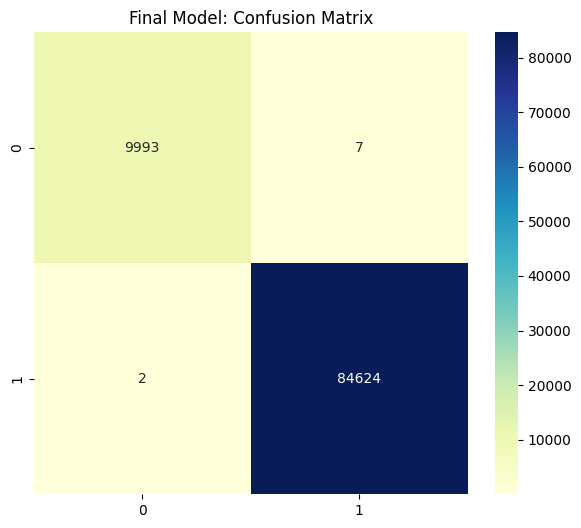

In [7]:
y_pred = (model_final.predict(X_test_lstm) > 0.5).astype(int)

print("\n📜 CLASS-WISE PERFORMANCE REPORT")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malicious']))

# Confusion Matrix
plt.figure(figsize=(7, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='YlGnBu')
plt.title('Final Model: Confusion Matrix')
plt.show()

In [8]:
model_save_path = r'C:\Users\aayis\OneDrive\Desktop\UWL\PROJECT\DNS_Covert_Channel_Detection\models'
if not os.path.exists(model_save_path):
    os.makedirs(model_save_path)

# Save Model, Scaler, and Features list
model_final.save(os.path.join(model_save_path, 'dns_covert_detector_final.h5'))
joblib.dump(scaler, os.path.join(model_save_path, 'dns_scaler_final.pkl'))
with open(os.path.join(model_save_path, 'final_features.txt'), 'w') as f:
    f.write(','.join(top_features_list))

print(f"✅ All assets saved to {model_save_path}")

✅ All assets saved to C:\Users\aayis\OneDrive\Desktop\UWL\PROJECT\DNS_Covert_Channel_Detection\models


In [9]:
#!/usr/bin/env python3
"""
QUICK VERIFICATION - Run this AFTER training to verify model works
"""

import os
import sys
import joblib
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model

print("\n" + "="*70)
print("POST-TRAINING VERIFICATION")
print("="*70)

model_dir = r"C:\Users\aayis\OneDrive\Desktop\UWL\PROJECT\DNS_Covert_Channel_Detection\models"

# Check files exist
print("\n📁 Checking files...")
files = {
    'Model': 'dns_covert_detector_final.h5',
    'Scaler': 'dns_scaler_final.pkl',
    'Features': 'final_features.txt'
}

all_exist = True
for name, filename in files.items():
    path = os.path.join(model_dir, filename)
    exists = os.path.exists(path)
    print(f"  {'✅' if exists else '❌'} {name}: {filename}")
    if not exists:
        all_exist = False

if not all_exist:
    print("\n❌ MISSING FILES! Training didn't complete properly!")
    sys.exit(1)

print("\n✅ All files exist!")

# Load everything
print("\n📦 Loading model, scaler, features...")
try:
    model = load_model(os.path.join(model_dir, 'dns_covert_detector_final.h5'))
    scaler = joblib.load(os.path.join(model_dir, 'dns_scaler_final.pkl'))
    with open(os.path.join(model_dir, 'final_features.txt'), 'r') as f:
        features = [x.strip() for x in f.read().split(',') if x.strip()]
    
    print(f"  ✅ Loaded successfully!")
    print(f"  Model input: {model.input_shape}")
    print(f"  Model output: {model.output_shape}")
    print(f"  Features: {len(features)}")
except Exception as e:
    print(f"  ❌ Loading failed: {e}")
    sys.exit(1)

# Test with known domains
print("\n🧪 Testing predictions...")

test_domains = [
    ('google.com', 'benign', 0.0, 0.3),
    ('xK9j2Lq8M3p7RtY4nW6vB1sD5fG8hJ0k.com', 'malicious', 0.6, 1.0),
    ('cisco-support.org', 'phishing', 0.3, 0.6),
]

def entropy(s):
    import math
    if not s: return 0
    freq = {}
    for c in s: freq[c] = freq.get(c, 0) + 1
    return -sum((v/len(s)) * math.log2(v/len(s)) for v in freq.values())

def extract_features(domain):
    # Simplified feature extraction
    subdomain = domain.split('.')[0]
    return {
        'dns_domain_name_length': len(subdomain),
        'character_entropy': entropy(subdomain),
        'numerical_percentage': sum(c.isdigit() for c in subdomain) / len(subdomain) if subdomain else 0,
        # Add zeros for other features
        **{feat: 0 for feat in features if feat not in ['dns_domain_name_length', 'character_entropy', 'numerical_percentage']}
    }

print()
all_good = True
for domain, expected_type, min_prob, max_prob in test_domains:
    feats = extract_features(domain)
    df = pd.DataFrame([feats])
    
    # Ensure all features present
    for feat in features:
        if feat not in df.columns:
            df[feat] = 0
    
    # Scale and predict
    scaled = scaler.transform(df[features])
    scaled = scaled.reshape(scaled.shape[0], 1, scaled.shape[1])
    prob = float(model.predict(scaled, verbose=0)[0][0])
    
    # Check if in expected range
    in_range = min_prob <= prob <= max_prob
    status = '✅' if in_range else '❌'
    
    print(f"  {status} {domain:40s} → {prob:.4f} (expected {min_prob:.1f}-{max_prob:.1f})")
    
    if prob == 0.0000 and expected_type != 'benign':
        print(f"      ⚠️ WARNING: Model returned 0.0000 for {expected_type}!")
        all_good = False
    
    if not in_range:
        all_good = False

print("\n" + "="*70)
if all_good:
    print("✅ MODEL IS WORKING CORRECTLY!")
    print("\nNext steps:")
    print("  1. Restart Flask: python new_app_FIXED.py")
    print("  2. Test: python debug_lstm_test.py")
    print("  3. Full test: python red_team_test.py")
else:
    print("⚠️ MODEL MAY HAVE ISSUES!")
    print("\nPossible problems:")
    print("  - Model not trained properly (stuck at 50% accuracy)")
    print("  - Wrong features saved")
    print("  - Scaler not fit correctly")
    print("\nCheck your training notebook output!")

print("="*70 + "\n")


POST-TRAINING VERIFICATION

📁 Checking files...
  ✅ Model: dns_covert_detector_final.h5
  ✅ Scaler: dns_scaler_final.pkl
  ✅ Features: final_features.txt

✅ All files exist!

📦 Loading model, scaler, features...
  ✅ Loaded successfully!
  Model input: (None, 1, 15)
  Model output: (None, 1)
  Features: 15

🧪 Testing predictions...

  ✅ google.com                               → 0.0000 (expected 0.0-0.3)
  ❌ xK9j2Lq8M3p7RtY4nW6vB1sD5fG8hJ0k.com     → 0.3601 (expected 0.6-1.0)
  ❌ cisco-support.org                        → 0.0000 (expected 0.3-0.6)

⚠️ MODEL MAY HAVE ISSUES!

Possible problems:
  - Model not trained properly (stuck at 50% accuracy)
  - Wrong features saved
  - Scaler not fit correctly

Check your training notebook output!

